## Filtered Positive Augmentation
Apply Venn-Abers calibrated filtering to the 1,924 raw synthetic positives.
Retain only those with high calibrated score and narrow interval width.
Retrain and evaluate against baseline and unfiltered augmented conditions.

In [1]:
import pandas as pd
import numpy as np
import os
os.chdir("..")

## Load embeddings and refit Venn-Abers calibrator
All embeddings loaded from disk. Base classifier retrained and calibrator
fitted in this session to ensure consistency — no cross-session score comparisons.

In [2]:
from sklearn.linear_model import LogisticRegression
from venn_abers import VennAbersCalibrator
from sentence_transformers import SentenceTransformer

# Load saved embeddings
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

# Retrain base classifier
clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
print("Base classifier trained.")

# Fit Venn-Abers calibrator
va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
print("Venn-Abers calibrator fitted.")

# Encode synthetic positives
df_syn = pd.read_parquet("data/synthetic/positive_raw.parquet")
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding synthetic positives...")
X_syn = model.encode(df_syn['sentence'].tolist(), show_progress_bar=True)
y_syn = df_syn['label'].values
print(f"Synthetic embeddings: {X_syn.shape}")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Base classifier trained.
Venn-Abers calibrator fitted.


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 324.00it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding synthetic positives...


Batches: 100%|██████████| 61/61 [00:29<00:00,  2.07it/s]

Synthetic embeddings: (1924, 384)


## Score synthetic positives with Venn-Abers calibrator
Compute calibrated point estimates and intervals for all 1,924 synthetic positives.
The interval width (p1 - p0) is the key quality signal — narrow intervals indicate
the classifier is genuinely confident, wide intervals indicate ambiguity.

In [4]:
# Check what methods are available on the fitted calibrator
print([m for m in dir(va_base) if not m.startswith('_')])

['cal_size', 'classes', 'cv_ensemble', 'estimator', 'fit', 'inductive', 'n_splits', 'precision', 'predict', 'predict_proba', 'random_state', 'shuffle', 'stratify', 'train_columns', 'train_proper_size', 'va_calibrator']


In [5]:
print(type(va_base.va_calibrator))
print([m for m in dir(va_base.va_calibrator) if not m.startswith('_')])

<class 'venn_abers.venn_abers.VennAbersMultiClass'>
['cal_size', 'classes', 'clf_ovo', 'cv_ensemble', 'estimator', 'fit', 'inductive', 'multi_class_model', 'multiclass_cal', 'multiclass_p0p1', 'multiclass_probs', 'multiclass_va_estimators', 'n_classes', 'n_splits', 'pairwise_id', 'precision', 'predict_proba', 'random_state', 'shuffle', 'stratify', 'train_proper_size']


In [ ]:
import inspect
print(inspect.getsource(va_base.va_calibrator.predict_proba))

In [8]:
# Get point estimates and intervals using correct parameter
p_prime, p0p1_list = va_base.va_calibrator.predict_proba(X_syn, p0_p1_output=True)

p_cal_scores = p_prime[:, 1]

print(f"p_prime shape: {p_prime.shape}")
print(f"p0p1_list length: {len(p0p1_list)}")
print(f"p0p1_list[0] type: {type(p0p1_list[0])}")
print(f"p0p1_list[0] shape: {p0p1_list[0].shape}")
print(f"p0p1_list[0][:3]: {p0p1_list[0][:3]}")

p_prime shape: (1924, 2)
p0p1_list length: 1
p0p1_list[0] type: <class 'numpy.ndarray'>
p0p1_list[0] shape: (1924, 2)
p0p1_list[0][:3]: [[0.04444444 0.05309735]
 [0.04444444 0.05309735]
 [0.01260504 0.01581028]]


In [9]:
# Extract p0, p1 and compute interval widths
p0p1 = p0p1_list[0]
p0_scores = p0p1[:, 0]
p1_scores = p0p1[:, 1]
interval_widths = p1_scores - p0_scores

print(f"Calibrated score range: [{p_cal_scores.min():.4f}, {p_cal_scores.max():.4f}]")
print(f"Interval width range:   [{interval_widths.min():.4f}, {interval_widths.max():.4f}]")
print(f"Mean calibrated score:  {p_cal_scores.mean():.4f}")
print(f"Mean interval width:    {interval_widths.mean():.4f}")
print(f"\nFirst 3 examples:")
for i in range(3):
    print(f"  p0={p0_scores[i]:.4f} | p1={p1_scores[i]:.4f} | "
          f"p={p_cal_scores[i]:.4f} | width={interval_widths[i]:.4f}")

Calibrated score range: [0.0017, 0.7500]
Interval width range:   [0.0010, 0.7333]
Mean calibrated score:  0.1383
Mean interval width:    0.0533

First 3 examples:
  p0=0.0444 | p1=0.0531 | p=0.0526 | width=0.0087
  p0=0.0444 | p1=0.0531 | p=0.0526 | width=0.0087
  p0=0.0126 | p1=0.0158 | p=0.0158 | width=0.0032


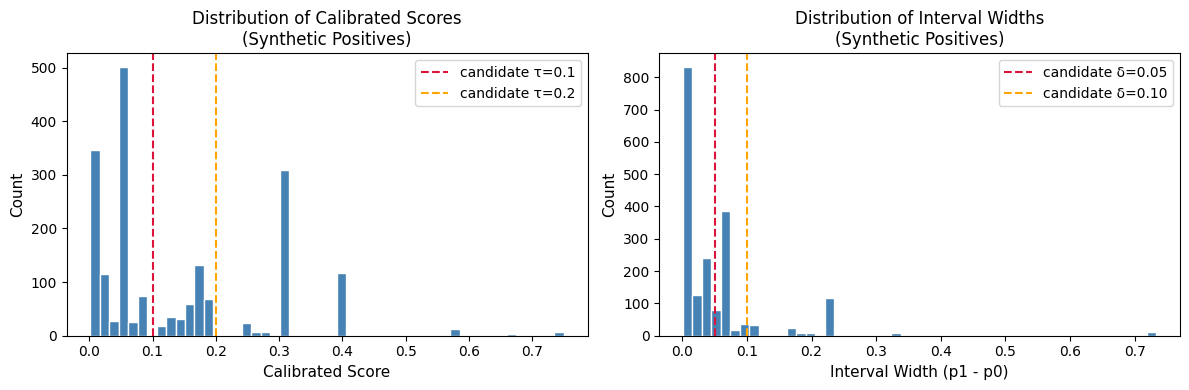

Saved.


In [10]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.hist(p_cal_scores, bins=50, color='steelblue', edgecolor='white')
ax1.set_xlabel('Calibrated Score', fontsize=11)
ax1.set_ylabel('Count', fontsize=11)
ax1.set_title('Distribution of Calibrated Scores\n(Synthetic Positives)', fontsize=12)
ax1.axvline(x=0.1, color='crimson', linestyle='--', label='candidate τ=0.1')
ax1.axvline(x=0.2, color='orange', linestyle='--', label='candidate τ=0.2')
ax1.legend(fontsize=10)

ax2.hist(interval_widths, bins=50, color='steelblue', edgecolor='white')
ax2.set_xlabel('Interval Width (p1 - p0)', fontsize=11)
ax2.set_ylabel('Count', fontsize=11)
ax2.set_title('Distribution of Interval Widths\n(Synthetic Positives)', fontsize=12)
ax2.axvline(x=0.05, color='crimson', linestyle='--', label='candidate δ=0.05')
ax2.axvline(x=0.10, color='orange', linestyle='--', label='candidate δ=0.10')
ax2.legend(fontsize=10)

plt.tight_layout()
plt.savefig("data/processed/synthetic_score_distribution.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [11]:
# Count survivors at different threshold combinations
thresholds = [(0.1, 0.05), (0.1, 0.10), (0.2, 0.05), (0.2, 0.10), (0.3, 0.10)]

print(f"Total synthetics: {len(p_cal_scores)}")
print(f"\n{'τ (score)':>12} {'δ (width)':>12} {'Survivors':>12} {'Pass rate':>12}")
print("-" * 52)
for tau, delta in thresholds:
    mask = (p_cal_scores >= tau) & (interval_widths <= delta)
    n = mask.sum()
    print(f"{tau:>12.2f} {delta:>12.2f} {n:>12} {n/len(p_cal_scores)*100:>11.1f}%")

Total synthetics: 1924

   τ (score)    δ (width)    Survivors    Pass rate
----------------------------------------------------
        0.10         0.05          113         5.9%
        0.10         0.10          621        32.3%
        0.20         0.05            0         0.0%
        0.20         0.10          310        16.1%
        0.30         0.10          310        16.1%


In [12]:
# Load train split to get seed sentences that belong to training set only
train_df = pd.read_parquet("data/processed/train.parquet")
train_sentences = set(train_df[train_df['label'] == 1]['sentence'].tolist())

# Filter synthetic set to only those seeded from training positives
train_seeded_mask = df_syn['seed_sentence'].isin(train_sentences)
print(f"Total synthetics: {len(df_syn)}")
print(f"Seeded from train positives: {train_seeded_mask.sum()}")
print(f"Seeded from cal/test positives (leakage): {(~train_seeded_mask).sum()}")

Total synthetics: 1924
Seeded from train positives: 1348
Seeded from cal/test positives (leakage): 576


In [13]:
# Keep only train-seeded synthetics
df_syn_clean = df_syn[train_seeded_mask].reset_index(drop=True)
X_syn_clean = X_syn[train_seeded_mask.values]
y_syn_clean = y_syn[train_seeded_mask.values]
p_cal_clean = p_cal_scores[train_seeded_mask.values]
interval_widths_clean = interval_widths[train_seeded_mask.values]

print(f"Clean synthetic set: {len(df_syn_clean)} sentences")

# Now apply calibrated filter on clean set
filter_mask_clean = (p_cal_clean >= 0.2) & (interval_widths_clean <= 0.10)
X_syn_filtered = X_syn_clean[filter_mask_clean]
y_syn_filtered = y_syn_clean[filter_mask_clean]
df_syn_filtered = df_syn_clean[filter_mask_clean].reset_index(drop=True)

print(f"After calibrated filter: {filter_mask_clean.sum()} survivors")
print(f"Pass rate: {filter_mask_clean.sum()/len(df_syn_clean)*100:.1f}%")
print(f"\nFiltered score range:  [{p_cal_clean[filter_mask_clean].min():.3f}, "
      f"{p_cal_clean[filter_mask_clean].max():.3f}]")
print(f"Filtered width range:  [{interval_widths_clean[filter_mask_clean].min():.3f}, "
      f"{interval_widths_clean[filter_mask_clean].max():.3f}]")

# Save clean filtered synthetics
df_syn_filtered.to_parquet("data/synthetic/positive_filtered.parquet", index=False)
print("\nSaved to data/synthetic/positive_filtered.parquet")

Clean synthetic set: 1348 sentences
After calibrated filter: 200 survivors
Pass rate: 14.8%

Filtered score range:  [0.312, 0.312]
Filtered width range:  [0.067, 0.067]

Saved to data/synthetic/positive_filtered.parquet


In [14]:
# Inspect a sample of filtered survivors
for i in range(10):
    print(f"[{i+1}] {df_syn_filtered.iloc[i]['sentence']}")
    print(f"     seed: {df_syn_filtered.iloc[i]['seed_sentence'][:80]}...")
    print()

[1] We have a high degree of uncertainty around closing the next transaction, unclear as to whether it's within this quarter.
     seed: One we expect to close, the next one we expect to close in the first quarter thi...

[2] It's difficult to predict exactly when we'll close the next deal, subject to various factors, but we're aiming to do so in the next quarter if everything stays on track.
     seed: One we expect to close, the next one we expect to close in the first quarter thi...

[3] We think that subject to final agreements and project announcements, the impact on demand growth from these customers may be felt as early as the late 2020s.
     seed: Subject to final agreements and project announcements, we expect to begin to see...

[4] We believe that price mix may decline in the range of low to mid-single digits, subject to a moderate offset from favorable carryover pricing actions and targeted investments in price and trade support.
     seed: We expect price mix may be down 

## Build filtered augmented train set and retrain
Combine 674 real training positives with 200 filtered synthetic positives.
New imbalance ratio reflects the filtered addition only.

In [15]:
# Build filtered augmented train set
X_train_filtered_aug = np.vstack([X_train, X_syn_filtered])
y_train_filtered_aug = np.concatenate([y_train, y_syn_filtered])

print(f"Original train:         {X_train.shape} | Positives: {y_train.sum()}")
print(f"Filtered augmented:     {X_train_filtered_aug.shape} | Positives: {y_train_filtered_aug.sum()}")
print(f"New imbalance ratio:    {(y_train_filtered_aug==0).sum()/y_train_filtered_aug.sum():.1f}:1")

# Train filtered augmented classifier
clf_filtered = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_filtered.fit(X_train_filtered_aug, y_train_filtered_aug)
print("\nFiltered augmented classifier trained.")

# Get raw scores
y_scores_filtered = clf_filtered.predict_proba(X_test)[:, 1]
y_pred_filtered = clf_filtered.predict(X_test)

# Fit Venn-Abers
va_filtered = VennAbersCalibrator(estimator=clf_filtered, inductive=True, cal_size=None)
va_filtered.fit(X_cal, y_cal)
y_scores_filtered_cal = va_filtered.predict_proba(X_test)[:, 1]

print("Venn-Abers calibration done.")

Original train:         (69510, 384) | Positives: 674
Filtered augmented:     (69710, 384) | Positives: 874
New imbalance ratio:    78.8:1

Filtered augmented classifier trained.
Venn-Abers calibration done.


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


## Evaluate filtered augmented classifier
Raw and calibrated metrics compared against baseline and unfiltered augmented.
Threshold optimization applied consistently across all calibrated conditions.

In [16]:
from sklearn.metrics import classification_report, f1_score

def optimal_threshold_f1(y_true, y_scores, thresholds=np.arange(0.01, 0.60, 0.01)):
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# Raw metrics
y_pred_filtered = clf_filtered.predict(X_test)
print("=== Filtered Augmented — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_filtered, digits=3))

# Calibrated metrics
t_filtered, _ = optimal_threshold_f1(y_test, y_scores_filtered_cal)
y_pred_filtered_cal = (y_scores_filtered_cal >= t_filtered).astype(int)
print(f"=== Filtered Augmented — Calibrated (threshold={t_filtered:.2f}) ===")
print(classification_report(y_test, y_pred_filtered_cal, digits=3))

=== Filtered Augmented — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.884     0.938     19669
           1      0.065     0.823     0.121       192

    accuracy                          0.884     19861
   macro avg      0.532     0.854     0.529     19861
weighted avg      0.989     0.884     0.930     19861

=== Filtered Augmented — Calibrated (threshold=0.12) ===
              precision    recall  f1-score   support

           0      0.992     0.991     0.991     19669
           1      0.140     0.156     0.148       192

    accuracy                          0.983     19861
   macro avg      0.566     0.573     0.569     19861
weighted avg      0.984     0.983     0.983     19861



In [17]:
# Also need baseline scores — recompute quickly
y_scores_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)
y_scores_base_cal = va_base.predict_proba(X_test)[:, 1]
t_base, _ = optimal_threshold_f1(y_test, y_scores_base_cal)
y_pred_base_cal = (y_scores_base_cal >= t_base).astype(int)

# Unfiltered augmented — retrain for consistency
from sklearn.linear_model import LogisticRegression as LR
X_train_aug = np.vstack([X_train, X_syn_clean])
y_train_aug = np.concatenate([y_train, y_syn_clean])
clf_aug = LR(class_weight='balanced', max_iter=1000, random_state=42)
clf_aug.fit(X_train_aug, y_train_aug)
y_scores_aug = clf_aug.predict_proba(X_test)[:, 1]
y_pred_aug = clf_aug.predict(X_test)
va_aug = VennAbersCalibrator(estimator=clf_aug, inductive=True, cal_size=None)
va_aug.fit(X_cal, y_cal)
y_scores_aug_cal = va_aug.predict_proba(X_test)[:, 1]
t_aug, _ = optimal_threshold_f1(y_test, y_scores_aug_cal)
y_pred_aug_cal = (y_scores_aug_cal >= t_aug).astype(int)

# Build comparison table
from sklearn.metrics import precision_score, recall_score

conditions = {
    'Baseline': (y_pred_base, y_pred_base_cal, t_base),
    'Unfiltered Aug': (y_pred_aug, y_pred_aug_cal, t_aug),
    'Filtered Aug': (y_pred_filtered, y_pred_filtered_cal, t_filtered),
}

print(f"{'Condition':<18} {'P(raw)':>8} {'R(raw)':>8} {'F1(raw)':>8} "
      f"{'P(cal)':>8} {'R(cal)':>8} {'F1(cal)':>8} {'τ':>6}")
print("-" * 80)

for name, (pred_raw, pred_cal, t) in conditions.items():
    p_raw = precision_score(y_test, pred_raw, zero_division=0)
    r_raw = recall_score(y_test, pred_raw, zero_division=0)
    f_raw = f1_score(y_test, pred_raw, zero_division=0)
    p_cal = precision_score(y_test, pred_cal, zero_division=0)
    r_cal = recall_score(y_test, pred_cal, zero_division=0)
    f_cal = f1_score(y_test, pred_cal, zero_division=0)
    print(f"{name:<18} {p_raw:>8.3f} {r_raw:>8.3f} {f_raw:>8.3f} "
          f"{p_cal:>8.3f} {r_cal:>8.3f} {f_cal:>8.3f} {t:>6.2f}")

Condition            P(raw)   R(raw)  F1(raw)   P(cal)   R(cal)  F1(cal)      τ
--------------------------------------------------------------------------------
Baseline              0.059    0.839    0.110    0.106    0.297    0.156   0.08
Unfiltered Aug        0.066    0.734    0.122    0.154    0.135    0.144   0.06
Filtered Aug          0.065    0.823    0.121    0.140    0.156    0.148   0.12


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\venn_abers\venn_abers.py:111: RuntimeWarning: All-NaN slice encountered
  if np.sum(np.isnan(np.nanmin(grads))) == 0:


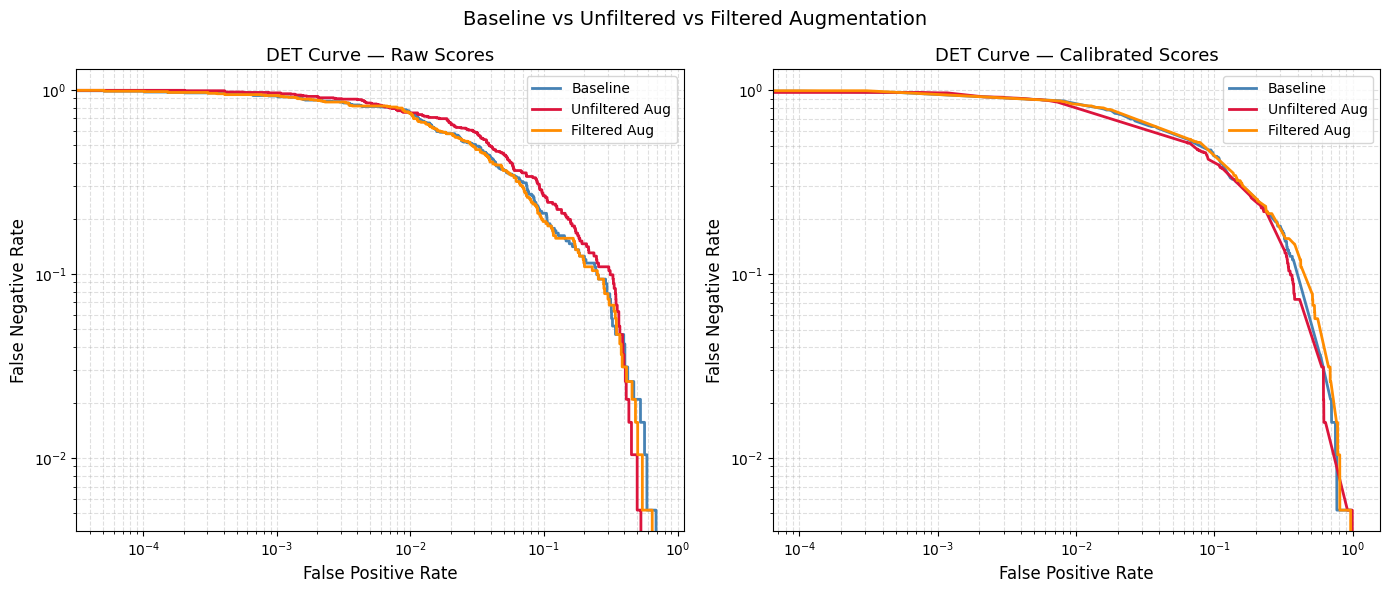

Saved.


In [18]:
from sklearn.metrics import det_curve
import matplotlib.pyplot as plt

# Compute DET curves
fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_scores_base_cal)
fpr_aug, fnr_aug, _ = det_curve(y_test, y_scores_aug)
fpr_aug_cal, fnr_aug_cal, _ = det_curve(y_test, y_scores_aug_cal)
fpr_filt, fnr_filt, _ = det_curve(y_test, y_scores_filtered)
fpr_filt_cal, fnr_filt_cal, _ = det_curve(y_test, y_scores_filtered_cal)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Raw
ax1.plot(fpr_base, fnr_base, label='Baseline', color='steelblue', linewidth=2)
ax1.plot(fpr_aug, fnr_aug, label='Unfiltered Aug', color='crimson', linewidth=2)
ax1.plot(fpr_filt, fnr_filt, label='Filtered Aug', color='darkorange', linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=10)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Calibrated
ax2.plot(fpr_base_cal, fnr_base_cal, label='Baseline', color='steelblue', linewidth=2)
ax2.plot(fpr_aug_cal, fnr_aug_cal, label='Unfiltered Aug', color='crimson', linewidth=2)
ax2.plot(fpr_filt_cal, fnr_filt_cal, label='Filtered Aug', color='darkorange', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=10)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Unfiltered vs Filtered Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig("data/processed/det_curve_all_positive_conditions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")